# Soubor dat o rakovině prsu

Datová sada Breast Cancer Wisconsin (Prognostic) shromažďuje údaje získané ze stovek případů rakoviny prsu, což je cenné pro prediktivní prognózu. 

Zahrnuje znaky, jako je poloměr, textura, plocha, kompaktnost a konkávnost, které byly vytvořeny z digitalizovaného aspirátu z tenké jehly (FNA) hmoty, aby se vytvořily charakteristiky buněčných jader přítomných v každém případu.

# Sloupce

* ID Number
* Time
* Tumor: Benigní, maligní nádor
* Radius: 
* Texture
* Perimeter
* Area
* Smoothness
* Compactness
* Concavity
* Concave Points
* Symmetry
* Fractal Dimension
* Radius Variance
* Texture Variance
* Perimeter Variance
* Area Variance
* Smoothness Variance
* Compactness Variance
* Concavity Variance
* Concave Points Variance
* Symmetry Variance
* Fractal Dimension Variance

# Úkol

Vytvoření modelu, který předpovídá benigní nebo maligní nádor na základě vlastností buněčných jader.

In [1]:
# Zadame SEED, aby vysledky neuronove modele se nemenili
import torch
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

torch.cuda.manual_seed_all(SEED)

## 1.1 Čtení dat ze souboru CSV

In [2]:
import pandas as pd
data = pd.read_csv ("../data/rakovina_prsou.csv")

In [3]:
# informace o struktuře souborů
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID Number                   569 non-null    int64  
 1   Time                        569 non-null    int64  
 2   Tumor                       569 non-null    str    
 3   Radius                      569 non-null    float64
 4   Texture                     569 non-null    float64
 5   Perimeter                   569 non-null    float64
 6   Area                        569 non-null    float64
 7   Smoothness                  569 non-null    float64
 8   Compactness                 569 non-null    float64
 9   Concavity                   569 non-null    float64
 10  Concave Points              569 non-null    float64
 11  Symmetry                    569 non-null    float64
 12  Fractal Dimension           569 non-null    float64
 13  Radius Variance             569 non-null    fl

## 1.2 Základní charakteristiky údajů

In [4]:
# prvních 10 řádků
data.head(10)

,ID Number,Time,Tumor,Radius,Texture,Perimeter,Area,Smoothness,Compactness,Concavity,...,Radius Variance,Texture Variance,Perimeter Variance,Area Variance,Smoothness Variance,Compactness Variance,Concavity Variance,Concave Points Variance,Symmetry Variance,Fractal Dimension Variance
0,0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,...,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193
1,1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,...,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532
2,2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,...,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571
3,3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,...,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208
4,4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,...,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115
5,5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,...,0.3345,0.8902,2.217,27.19,0.007510,0.03345,0.03672,0.01137,0.02165,0.005082
6,6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,...,0.4467,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179
7,7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,...,0.5835,1.3770,3.856,50.96,0.008805,0.03029,0.02488,0.01448,0.01486,0.005412
8,8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,...,0.3063,1.0020,2.406,24.32,0.005731,0.03502,0.03553,0.01226,0.02143,0.003749
9,9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,...,0.2976,1.5990,2.039,23.94,0.007149,0.07217,0.07743,0.01432,0.01789,0.010080


In [5]:
data.describe()

,ID Number,Time,Radius,Texture,Perimeter,Area,Smoothness,Compactness,Concavity,Concave Points,...,Radius Variance,Texture Variance,Perimeter Variance,Area Variance,Smoothness Variance,Compactness Variance,Concavity Variance,Concave Points Variance,Symmetry Variance,Fractal Dimension Variance
count,569.000000,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,284.000000,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795
std,164.400426,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646
min,0.000000,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895
25%,142.000000,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248
50%,284.000000,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187
75%,426.000000,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558
max,568.000000,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,...,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840


### Popis dat

- **ID Number**: Pořadové číslo záznamu v tabulce.

- **Time**: pravděpodobně identifikační číslo pacienta (ID).

- **Tumor**: M – maligní/zhoubný, B – benigní/nezhoubný.

- **Radius**: průměrná vzdálenost od středu k okrajům jádra.

- **Texture**: Textura.

- **Perimeter**: Obvod jádra buňky.

- **Area**: Plocha jádra buňky.

- **Smoothness**: Hladkost.

- **Compactness**: Kompaktnost (míra celistvosti tvaru jádra).

- **Concavity**: Prohlubně (závažnost vnořených částí obrysu).

- **Concave Points**: Konkávní body (počet nejvýraznějších prohlubní v obrysu).

- **Symmetry**: Symetrie jádra.

- **Fractal Dimension**: Fraktální dimenze (členitost nebo složitost okraje buňky).

**Variance sloupce** (např. Radius Variance, Area Variance atd.) představují standardní chybu nebo míru variability každé vlastnosti v rámci jednoho vzorku. Ukazují, jak moc se buňky od sebe v daném parametru liší.

Sloupec Tumor je textového datového typu, je potřeba ho změnit na číselný typ.

Sloupec ID Number můžeme smazat. Sloupec Time obsahuje abnormalni čísla, nesouvisí s biologickými vlastnostmi nádoru a pravdepodobně označuje identifikační čísla pacientů.

Ostatní sloupce je potřeba standardizovat.

## 1.3 Vyčištění dat

In [6]:
# Odstranění sloupců, které nejsou užitečné pro model
data = data.drop(columns=["ID Number", "Time"])

In [7]:
# Ověření, že sloupce byly úspěšně odstraněny
print(data.shape)
print(data.columns.tolist())

(569, 21)
['Tumor', 'Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness', 'Compactness', 'Concavity', 'Concave Points', 'Symmetry', 'Fractal Dimension', 'Radius Variance', 'Texture Variance', 'Perimeter Variance', 'Area Variance', 'Smoothness Variance', 'Compactness Variance', 'Concavity Variance', 'Concave Points Variance', 'Symmetry Variance', 'Fractal Dimension Variance']


In [8]:
#kontrola zda data obsahuji NULL
print (data.isnull().sum())

Tumor                         0
Radius                        0
Texture                       0
Perimeter                     0
Area                          0
Smoothness                    0
Compactness                   0
Concavity                     0
Concave Points                0
Symmetry                      0
Fractal Dimension             0
Radius Variance               0
Texture Variance              0
Perimeter Variance            0
Area Variance                 0
Smoothness Variance           0
Compactness Variance          0
Concavity Variance            0
Concave Points Variance       0
Symmetry Variance             0
Fractal Dimension Variance    0
dtype: int64


## 1.4 Encoding dat
Začneme převodem textových hodnot sloupci Trumor na číselné (M = 1, B = 0)

In [9]:
data["Tumor"] = data["Tumor"].map({"M": 1, "B": 0})

In [10]:
data.head(10)

,Tumor,Radius,Texture,Perimeter,Area,Smoothness,Compactness,Concavity,Concave Points,Symmetry,...,Radius Variance,Texture Variance,Perimeter Variance,Area Variance,Smoothness Variance,Compactness Variance,Concavity Variance,Concave Points Variance,Symmetry Variance,Fractal Dimension Variance
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115
5,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,0.3345,0.8902,2.217,27.19,0.007510,0.03345,0.03672,0.01137,0.02165,0.005082
6,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,0.4467,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179
7,1,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,0.5835,1.3770,3.856,50.96,0.008805,0.03029,0.02488,0.01448,0.01486,0.005412
8,1,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,0.3063,1.0020,2.406,24.32,0.005731,0.03502,0.03553,0.01226,0.02143,0.003749
9,1,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,0.2976,1.5990,2.039,23.94,0.007149,0.07217,0.07743,0.01432,0.01789,0.010080


## 1.5 Rozdělení hodnot
Udělame vizualizace rozložení dat ve sloupcích by mohla odhalit zkreslené, abnormální hodnoty.

In [11]:
# Import knihoven pro vizualizaci
import seaborn as sns
import matplotlib.pyplot as plt

Histogramy rozložení hodnot pro všechny sloupce

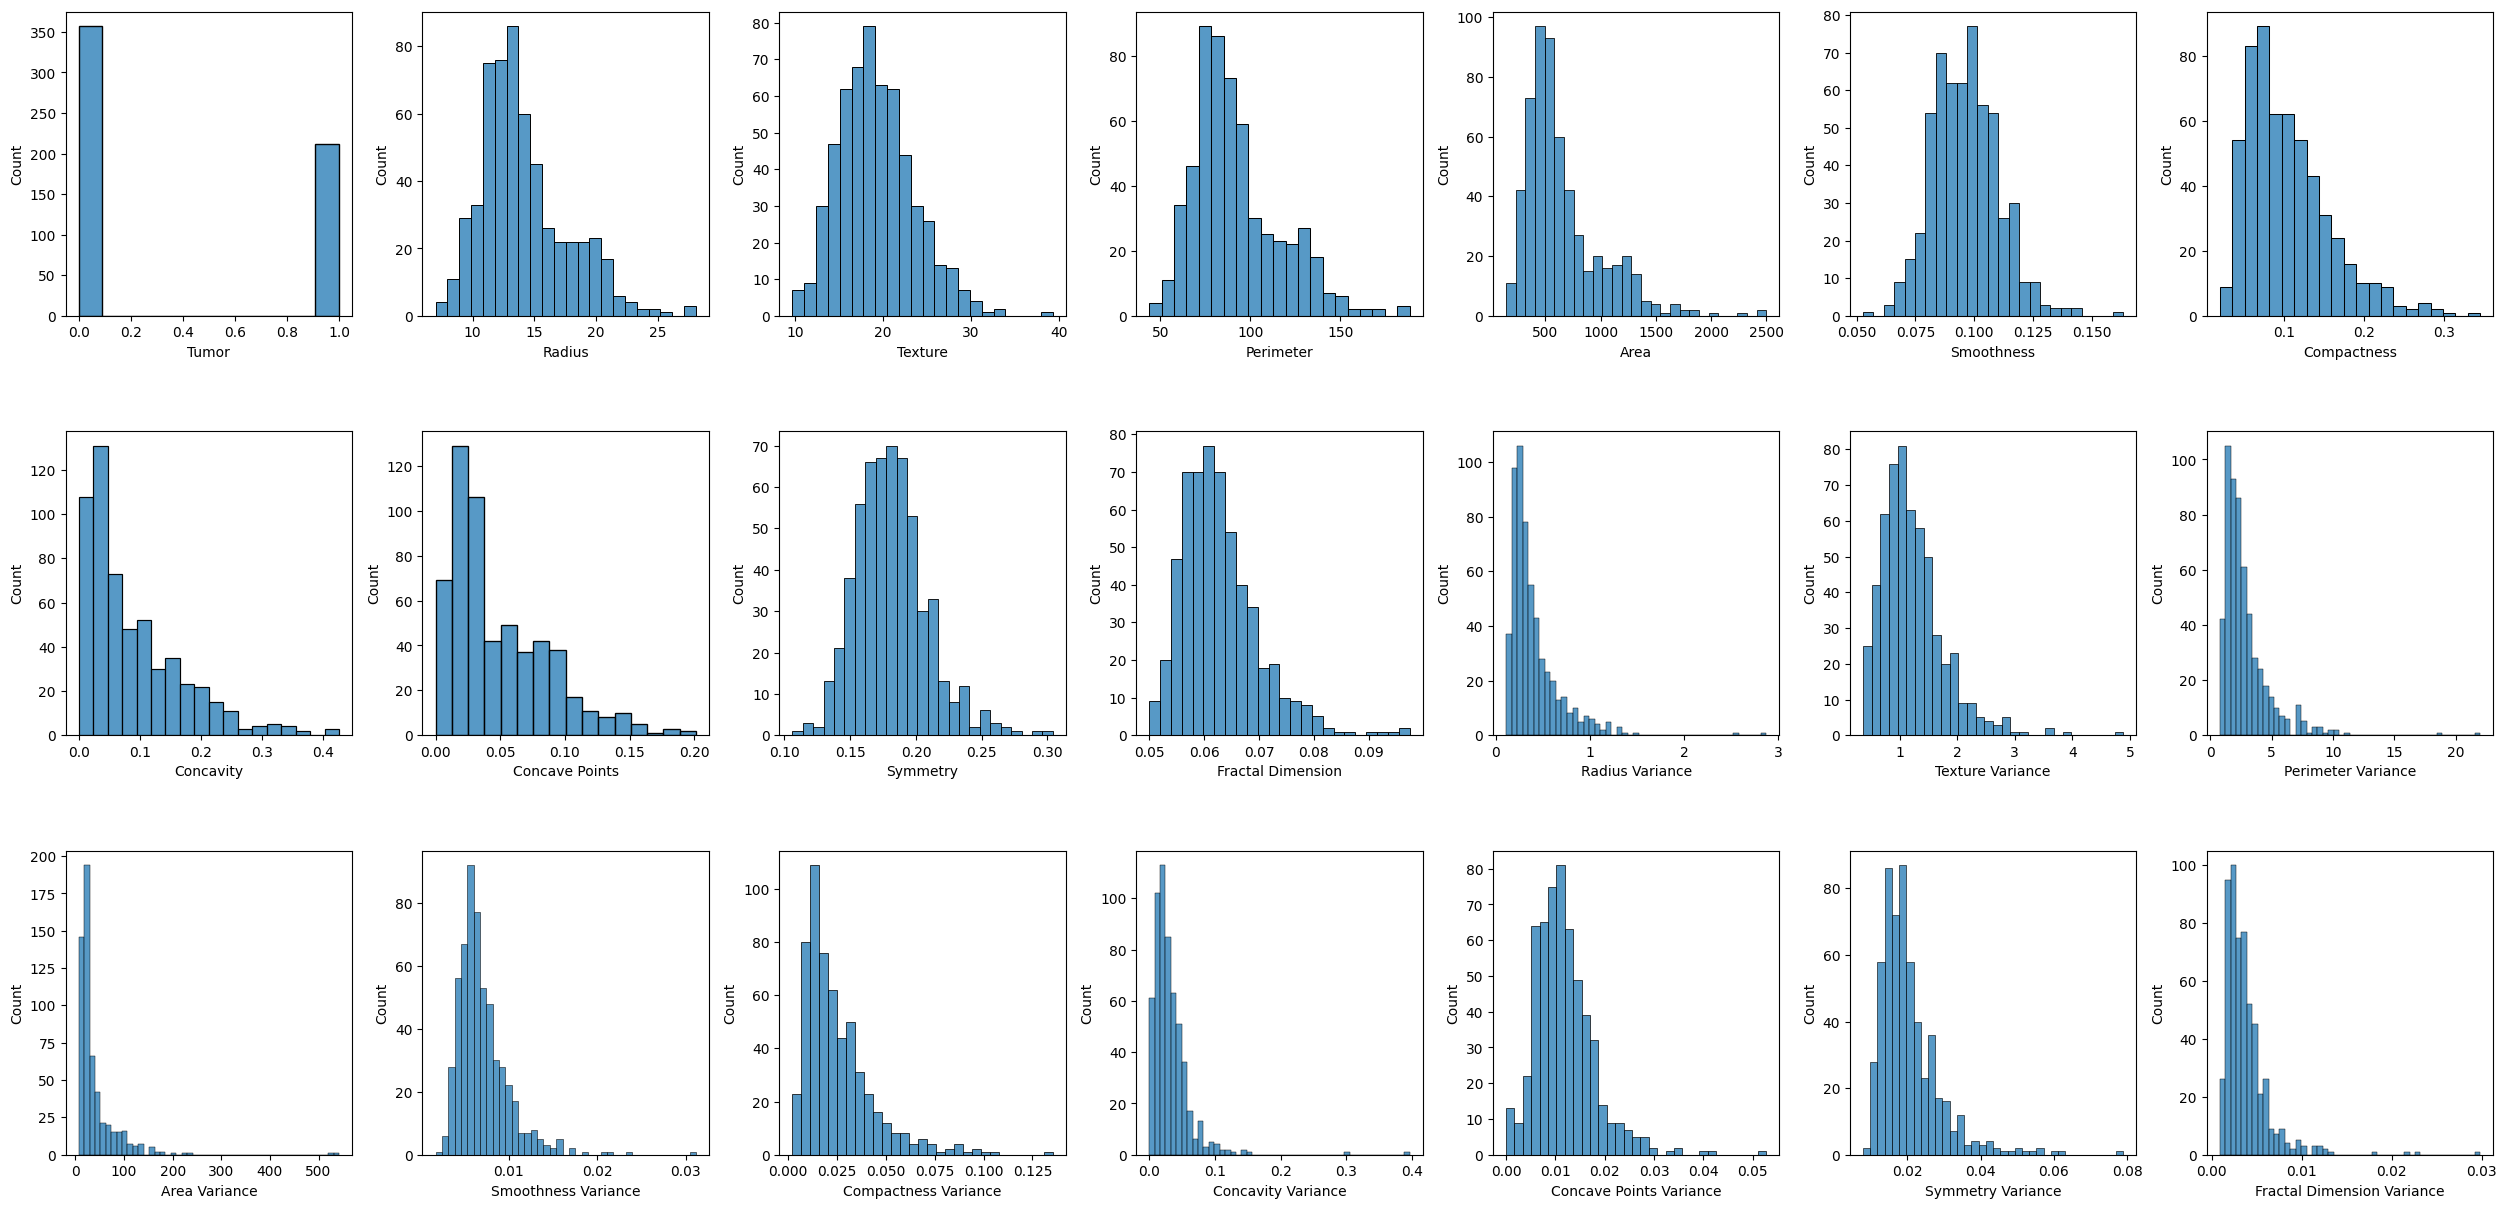

In [12]:
fig, axs = plt.subplots(ncols=7, nrows=3, figsize=(25, 12))
index = 0
axs = axs.flatten()
for k,v in data.items():
    sns.histplot(v, ax=axs[index])
    index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

Krabicový graf pro odhalení odlehlých hodnot

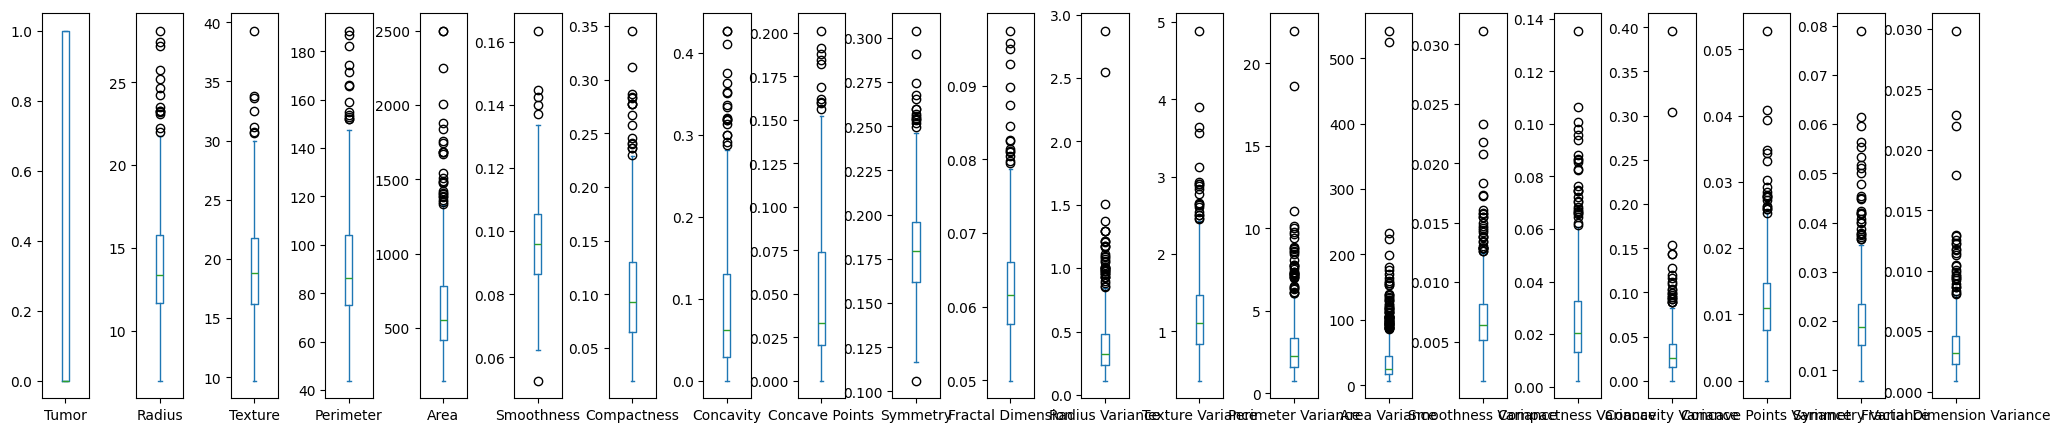

In [13]:
data.plot(
    kind='box',
    subplots=True,
    sharey=False,
    figsize=(25, 5)
)
plt.subplots_adjust(wspace=1)
plt.show()

Většina sloupců obsahuje odlehlé hodnoty (outliers).

Standardizace pomůže snížit vliv odlehlých hodnot na model.

### Korelační matice - zobrazíme si i vztahy mezi daty.

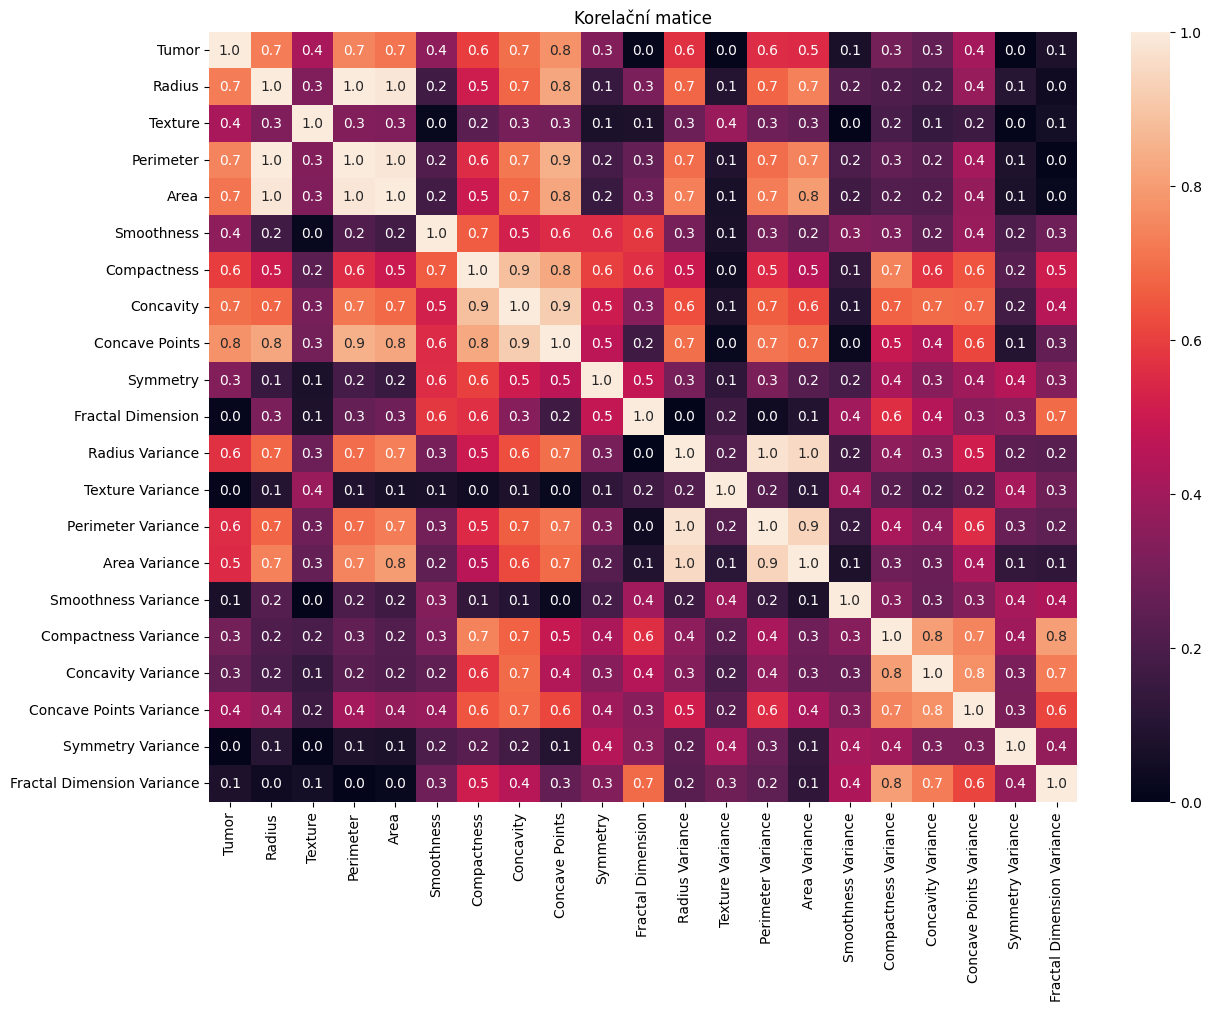

In [14]:
corr = data.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr.abs(), annot=True, vmin=0, vmax=1, fmt=".1f")
plt.title("Korelační matice")
plt.savefig('../images/correlation_matrix.png', dpi=100, bbox_inches='tight')

Tumor je cílová proměnná. Nejsilnější vztah má s Concave Points (0,8), Concavity (0,7), Radius (0,7), Perimeter (0,7) a Area (0,7).

V matici se však vyskytuje multikolinearita (sloupce nesoucí stejnou informaci). Sloupce Radius, Perimeter a Area jsou téměř identické (korelace 1,0). 

To samé platí pro Perimeter Variance a Area Variance (korelace 0,9) nebo Compactness a Concavity (0,9).

Slabý vztah s Tumor mají sloupce Fractal Dimension (0,0), Texture Variance (0,0) a Symmetry Variance (0,0) - tyto příznaky budou pro model méně užitečné.

# 2. Příprava a standardizace dat

## 2.1 Výběr proměnných

Podle analýzy korelační matice odstraníme následující sloupce:

Slabý vztah s proměnnou Tumor:
- Fractal Dimension (0,0)
- Texture Variance (0,0)  
- Symmetry Variance (0,0)

Multikolinearita:
- Area a Perimeter (korelace 1,0 s Radius) → ponecháme pouze Radius
- Concavity (korelace 0,9 s Compactness) → ponecháme pouze Compactness
- Area Variance (korelace 0,9 s Perimeter Variance) → ponecháme pouze Perimeter Variance

In [15]:
data = data.drop(columns=["Fractal Dimension", "Texture Variance", "Symmetry Variance", "Area", "Perimeter", "Concavity", "Area Variance"])

In [16]:
# Ověření výsledku
print(data.shape)
print(data.columns.tolist())

(569, 14)
['Tumor', 'Radius', 'Texture', 'Smoothness', 'Compactness', 'Concave Points', 'Symmetry', 'Radius Variance', 'Perimeter Variance', 'Smoothness Variance', 'Compactness Variance', 'Concavity Variance', 'Concave Points Variance', 'Fractal Dimension Variance']


## 2.2 Standardizace dat

Každý sloupec má jiný rozsah hodnot (např. Area až 2500, Smoothness ~0,09).
Před vložením dat do modelu provedeme standardizaci, aby žádná proměnná
nedominovala ostatním pouze kvůli své velikosti.

In [17]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib

In [18]:
# Rozdělení dat na vstupní proměnné (X) a cílovou proměnnou (y)
X = data.drop(columns=["Tumor"]).values
y = data["Tumor"].values

In [19]:
# Standardizace vstupních dat pomocí StandardScaler
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [20]:
# Ověření výsledku - průměr by měl být ~0, std ~1
print("Průměr:", np.average(X_norm, axis=0).round(2))
print("Std:", np.std(X_norm, axis=0).round(2))

Průměr: [-0.  0. -0.  0. -0.  0.  0. -0. -0.  0.  0.  0. -0.]
Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Standardizace proběhla úspěšně. Průměr všech sloupců je ~0 
a směrodatná odchylka je ~1. Data jsou připravena pro trénování modelu.

In [21]:
# Uložení scaleru pro pozdější použití při inferenci
joblib.dump(scaler, "scaler.bin", compress=True)

['scaler.bin']

## 2.3 Rozdělení dat

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
train_ratio = 0.75
validation_ratio = 0.15
test_ratio = 0.10

# Trénovací sada 75% celého datasetu
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=1 - train_ratio, random_state=42) # random_state=42 - reprodukovatelnost

# Validační 15%, testovací 10% z původního datasetu
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio),
    random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(426, 13)
(85, 13)
(58, 13)


## 3. Klasický model - SVM
SVM je algoritmus strojového učení používaný pro klasifikaci a částečně i pro regresi.

* **Základní myšlenka**: Najít hranici (hyperplane), která nejlépe odděluje různé třídy ve vstupních datech.
* **Maximalizace okraje**: SVM se snaží najít hyperplane tak, aby vzdálenost mezi hranicí a nejbližšími body obou tříd byla co největší (tyto body se nazývají support vectors).
* **Lineárně separovatelné data**: Pokud lze třídy oddělit přímkou (2D) nebo hyperplane (více dimenzí), SVM najde optimální oddělující hyperplane.
* **Nelineární data**: Pomocí kernel tricku (např. RBF, polynomial) lze data mapovat do vyšší dimenze, kde jsou lineárně oddělitelná.
* **Regularizace**: Parametr C ovlivňuje kompromis mezi maximalizací okraje a minimalizací chyb klasifikace na trénovacích datech.

In [24]:
from sklearn import svm

### 3.1 Trénování modelu
Vytvoření a natrénování lineárního SVM modelu

In [25]:
svm_model = svm.SVC(kernel = 'linear', random_state = 0)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [26]:
# Spuštění modelu na validačních datech
y_pred = svm_model.predict(X_val)

In [27]:
print(y_pred)

[1 1 0 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0
 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 1 1 1
 0 1 0 0 0 0 1 0 0 1 1]


### 3.2 Ověření modelu

In [28]:
from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=svm_model, X=X_train, y=y_train)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 94.37 %
Standard Deviation: 2.01 %


Model SVM s lineárním kernelem dosáhl průměrné přesnosti 94,37%.
Nízká směrodatná odchylka (2,01 %) znamená, že model je stabilní a nepřeučený.

#### Confusion matrix

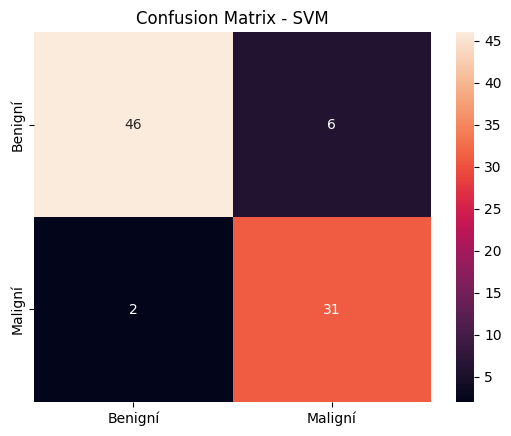

In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

cf_matrix = confusion_matrix(y_val, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d',
            xticklabels=['Benigní', 'Maligní'],
            yticklabels=['Benigní', 'Maligní'])
plt.title("Confusion Matrix - SVM")
plt.savefig('../images/confusion_matrix_svm.png', dpi=100, bbox_inches='tight')

- 46 správně označeno jako benigní (True Negative)
- 31 správně označeno jako maligní (True Positive)
- 6 benigní označeno jako maligní (False Positive)
- 2 maligní označeno jako benigní (False Negative)

2 případy model označil maligní nádor jako benigní. Chyba nastala pouze 2× z 85 případů, což je dobrý výsledek.

In [30]:
# Skóre
accuracy_score(y_val, y_pred)

0.9058823529411765

Přesnost na validačních datech: 90,59 %

Model správně klasifikoval 77 z 85 případů.
Pouze 2 případy maligního nádoru byly chybně označeny.

### 3.3 Vizualizace modelu

In [31]:
from sklearn.inspection import DecisionBoundaryDisplay

Klíčové pro SVM jsou support vektory. Jedná se o body, které určují hranici.

In [32]:
svm_model.support_vectors_

array([[ 1.74017844e-01,  1.42657394e+00, -9.68581676e-01,
        -6.10256289e-01, -4.81035739e-01,  1.03618778e-01,
        -3.68399488e-01, -3.41105410e-01, -7.55356929e-01,
        -7.68936043e-01, -4.11933448e-01,  1.44993205e-01,
        -4.42139456e-01],
       [ 1.59817134e-01, -1.23559085e+00,  4.79635067e-01,
         1.50207561e+00,  3.63201303e-01,  1.00175085e+00,
         5.08999468e-01,  9.54884729e-01,  9.78380031e-01,
         1.50688600e+00,  6.92526986e-01,  6.49465265e-01,
         6.23772826e-01],
       [ 1.14374863e-01, -1.23559085e+00,  9.63560073e-01,
        -2.25920286e-01,  4.13499568e-01, -5.90060467e-01,
        -3.57932779e-01, -3.57936451e-01, -3.02671908e-01,
        -7.24783307e-01, -5.22014764e-01, -7.07456503e-02,
        -8.77179487e-02],
       [ 9.73340110e-02,  1.32651006e+00, -5.68631893e-01,
         3.53615954e-01, -2.58433672e-01,  2.20448967e-01,
        -5.44889858e-01, -1.24282002e-01,  3.23416745e-02,
         1.17657882e+00,  2.12081724e

Připravíme se funkci, která zobrazí naměřené hodnoty, support vektory a příslušnost ke třídě pomocí barvy a i hranice tříd.

In [33]:
def SVM_vizualization (svm_model, X, y, title, xlabel, ylabel):
    # Zobrazení hranice rozhodování
    disp = DecisionBoundaryDisplay.from_estimator(
        svm_model,
        X,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,        
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)    

    # Zobrazení bodů
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")

    # Zobrazení support vektorů - větší kroužky
    try:
        plt.scatter(svm_model.support_vectors_[:,0], svm_model.support_vectors_[:,1] , s=40, edgecolors="k", facecolors='none')
    except:
        pass

Funkce DecisionBoundaryDisplay vyžaduje pouze 2 příznaky.

Pro vizualizaci natrénujeme pomocný model pouze na 2 nejdůležitějších příznacích podle korelační matice:
Concave Points (0,8) a Radius (0,7).

In [34]:
X_vis = data[['Concave Points', 'Radius']].values

# Standardizace pouze těchto 2 příznaků
scaler_vis = StandardScaler()
X_vis_norm = scaler_vis.fit_transform(X_vis)

# Rozdělení na trénovací a testovací
X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis_norm, y, test_size=0.25, random_state=42)

# Trénování modelu pouze pro vizualizaci
svm_vis = svm.SVC(kernel='linear', random_state=42)
svm_vis.fit(X_vis_train, y_vis_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


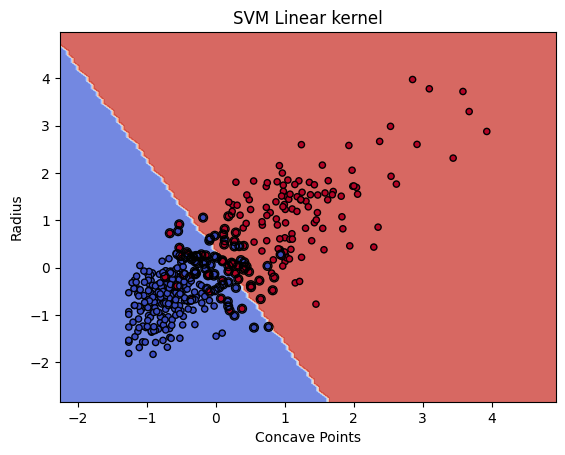

In [35]:
# Zobrazení hranice rozhodování
SVM_vizualization(svm_vis, X_vis_train, y_vis_train, "SVM Linear kernel", "Concave Points", "Radius")
plt.savefig('../images/svm_decision_boundary.png', dpi=100, bbox_inches='tight')

Graf ukazuje hranici (hyperplane) mezi benigními (modrá) a maligními (červená) nádory.

**Benigní** nádory mají malý Radius a málo Concave Points.
**Maligní** nádory mají velký Radius a hodně Concave Points.

### 3.4 Jiné kernely

Vyzkoušíme různé kernely a porovnáme jejich přesnost.
Kernel určuje jak SVM rozděluje data - lineárně nebo křivkou.

In [36]:
C = 1.0

#### Lineární kernel

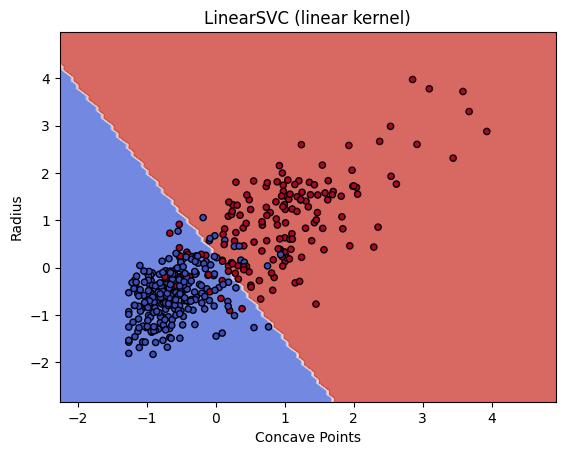

In [37]:
svm_linearsvc = svm.LinearSVC(C=C, max_iter=10000)
svm_linearsvc.fit(X_vis_train, y_vis_train)
SVM_vizualization(svm_linearsvc, X_vis_train, y_vis_train, "LinearSVC (linear kernel)", "Concave Points", "Radius")


In [38]:
# Skóre
svm_linearsvc.score(X_vis_test, y_vis_test)

0.9090909090909091

#### RBF kernel

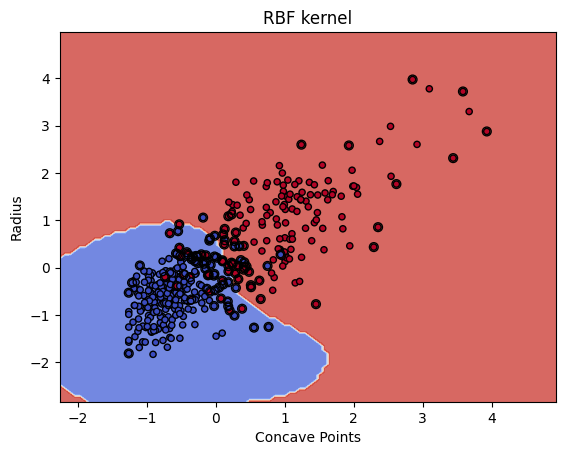

In [39]:
C = 1.0
svm_rbf = svm.SVC(kernel='rbf', gamma=0.7, C=C)
svm_rbf.fit(X_vis_train, y_vis_train)
SVM_vizualization(svm_rbf, X_vis_train, y_vis_train, "RBF kernel", "Concave Points", "Radius")

In [40]:
# Skóre
svm_rbf.score(X_vis_test, y_vis_test)

0.9090909090909091

#### Polynomální kernel

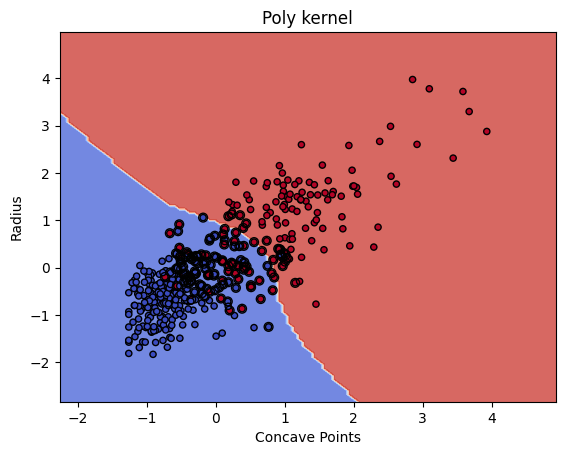

In [41]:
svm_poly = svm.SVC(kernel='poly', degree=3, gamma='auto', C=C)
svm_poly.fit(X_vis_train, y_vis_train)
SVM_vizualization(svm_poly, X_vis_train, y_vis_train, "Poly kernel", "Concave Points", "Radius")

In [42]:
# Skóre
svm_poly.score(X_vis_test, y_vis_test)

0.9090909090909091

Všechny kernely dosáhly stejné přesnosti na 2 příznacích. 
Rozdíl je vidět pouze ve tvaru hranice rozhodování.
Možná, že výběr jiných příznaků by to změnil.

### 3.5 Hyperparametry - GridSearchCV

SVM má více parametrů, které ovlivňují přesnost modelu.

GridSearchCV automaticky vyzkouší všechny zadané kombinace 
parametrů a vrátí tu nejlepší. Tím odpadá ruční experimentování.

scikit knihovna na to má již připravenou funkci.

In [43]:
from sklearn.model_selection import GridSearchCV

svc = svm.SVC()
params = [
    {"kernel": ["poly"], "C": [1, 5, 10, 50], "degree": [1, 2, 3, 4], "gamma": [0.1, 0.3, 0.7, 1, 5]},
    {"kernel": ["rbf"], "C": [1, 5, 10], "gamma": [0.1, 0.5, 1, 5]},    
]

clf = GridSearchCV(estimator=svc, param_grid=params, cv=5, verbose=1)
clf.fit(X_train, y_train)

Fitting 5 folds for each of 92 candidates, totalling 460 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [1, 5, ...], 'degree': [1, 2, ...], 'gamma': [0.1, 0.3, ...], 'kernel': ['poly']}, {'C': [1, 5, ...], 'gamma': [0.1, 0.5, ...], 'kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

Zobrazení skóre nejlepšího modelu.

In [44]:
clf.score(X_val, y_val)

0.9294117647058824

Zobrazení vstupních parametrů nejlepšího modelu.

In [45]:
clf.best_params_

{'C': 1, 'degree': 1, 'gamma': 0.7, 'kernel': 'poly'}

GridSearchCV zlepšil přesnost oproti základnímu lineárnímu modelu (90,59 % → 92,94 %).

Vizualizace je možná pouze pro modely trénované na 2 příznacích.
Hlavní model (clf) používá 13 příznaků - vizualizace není možná.

### 3.6 Uložení modelu

In [46]:
import pickle
filename = 'svm_model.sav'
pickle.dump(clf, open(filename, 'wb'))

In [47]:
loaded_model = pickle.load(open(filename, 'rb'))
print("Model úspěšně uložen a načten")
print(f"Přesnost načteného modelu: {loaded_model.score(X_val, y_val)*100:.2f} %")

Model úspěšně uložen a načten
Přesnost načteného modelu: 92.94 %


# 4. Neuronová síť

Vytvoříme model pomocí jednoduché dopředné neuronové sítě v frameworku PyTorch.
Na rozdíl od SVM, neuronová síť se učí sama rozpoznávat vzory v datech
prostřednictvím vrstev propojených neuronů a optimalizace vah.

## 4.1 Import a inicializace

In [48]:
# Importujeme knihovny pro PyTorch a metriky klasifikace
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [49]:
# Zjistíme, zda je dostupné GPU, jinak použijeme CPU
print(torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

2.9.1+cu130
Using: cpu


c:\Users\mirov\Documents\DATA\PROJECTS\UNI\II_ROK\LS\BMLAI\breast-cancer-project\.venv\Lib\site-packages\torch\cuda\__init__.py:182: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:88.)
  return torch._C._cuda_getDeviceCount() > 0


## 4.2 Struktura
Vytvoříme třídu ClassificationNet pro binární klasifikaci (benigní/maligní).

Na výstupu používáme funkci Sigmoid, která převádí výsledek na pravděpodobnost v rozsahu [0, 1].
Práh 0.5 je přirozený střed. Hodnoty nad 0.5 označíme jako maligní (1), pod 0.5 jako benigní (0).

* nn.Module je základní třídou pro všechny modely v PyTorch.
* nn.Linear(a, b) = hustá vrstva (Dense) s a vstupy a b výstupy.
* nn.ReLU() = aktivační funkce.
* nn.Sigmoid() = výstup bude v rozsahu [0, 1]
* forward() říká: „když přijde vstup, pošli ho vrstvami“.

In [50]:
print(X_train.shape) #kontrola příznaků

(426, 13)


In [51]:
class ClassificationNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(13, 128), # Vstupní vrstva: 13 příznaků → 128 neuronů
            nn.ReLU(),
            nn.Linear(128, 64), # Skrytá vrstva: 128 → 64
            nn.ReLU(),
            nn.Linear(64, 32), # Skrytá vrstva: 64 → 32
            nn.ReLU(),
            nn.Linear(32, 16), # Skrytá vrstva: 32 → 16
            nn.ReLU(),
            nn.Linear(16, 1), # Výstupní vrstva: 1 neuron (pravděpodobnost)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

Vytvoření instance modelu a vypsání struktury vrstev.

In [52]:
model = ClassificationNet()
model.to(device)
print(model)

ClassificationNet(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


Struktura je v pořadku

PyTorch nepracuje s numpy ani pandas – chce vlastní formát: **tensor**.

* Data převedeme na torch.tensor

In [53]:
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
y_train_torch = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_torch = torch.tensor(X_val, dtype=torch.float32)
y_val_torch = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_test_torch = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

Jednotlivé tensory zabalíme do TensorDataset.

TensorDataset je dvojice vstupních a výstupních tensorů (X, y).

In [54]:
train_ds = TensorDataset(X_train_torch, y_train_torch)
val_ds   = TensorDataset(X_val_torch, y_val_torch)
test_ds  = TensorDataset(X_test_torch, y_test_torch)

Vytvoříme DataLoader, který je během trénování dávkuje (batch).

DataLoader umí:
* dávkovat data po částech,
* míchat je (shuffle),
* efektivně je doručovat modelu.

V Keras se toto děje interně. V PyTorch to děláme ručně → větší kontrola.

In [55]:
batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

### Ztrátová funkce a optimalizátor

Před trénováním musíme zvolit:

* **Ztrátovou funkci (Loss)** – měří, jak moc se předpověď liší od skutečné hodnoty.
  Pro binární klasifikaci lepši použit **Binary Cross-Entropy (BCELoss)**. protoře výstup sítě
  je pravděpodobnost (0-1) a BCE ji porovnává se skutečnou třídou (0 nebo 1).

* **Optimalizátor** – algoritmus, který aktualizuje váhy sítě na základě gradientů.
  Používáme **Adam** s learning rate 0.001.

In [56]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 4.3 Trénování modelu

In [57]:
max_epochs = 200        # maximální délka trénování
patience = 30           # po kolika epoch se trénování zastaví, pokud se ztrátová funkce nesnižuje
best_val_loss = np.inf  # výchozí hodnota nejlepšího běhu
epochs_no_improve = 0   # kolik epoch se ztrátová funkce nesnížila

# Inicializace historie trénování
history_loss = []
history_mae = []

In [58]:
# Hlavní trénovací smyčka
for epoch in range(max_epochs):
    # nastavení modelu do trénovacího módu
    model.train()

    # budeme si ukládat hodnotu ztrátové funkce (loss) za každý batch. Na konci epochy se z nich spočítá průměr → to je trénovací loss epochy.
    train_losses = []

    # to samé pro MAE
    train_mae = []


    # train_loader je objekt, který
    #   - rozdělí data na malé části (mini-batche),
    #   - v každé iteraci vrátí dvojici x_batch (vstupy) a y_batch (výstupy),
    #   - batch má velikost 32 (protože jsme nastavili batch_size=32).

    # Batchování je zásadní, protože:
    #   - na GPU neběží dobře výpočet po jednom vzorku,
    #   - mini-batch stabilizuje gradienty, zrychluje trénování.
    for x_batch, y_batch in train_loader:

        # PyTorch nenuluje gradienty sám od sebe. Gradienty z předchozího batch zůstávají uložené, a pokud je nesmažeme, sčítají se → špatné výsledky.
        optimizer.zero_grad()

        # případné nahrání dat na GPU
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)   

        # forward fáze
        outputs = model(x_batch)

        # Výpočet BCE ztrátové funkce
        loss = criterion(outputs, y_batch)

        # MAE – průměrná absolutní odchylka mezi pravděpodobností a skutečnou třídou
        mae = nn.L1Loss()(outputs, y_batch)

        # zpětná fáze 
        loss.backward()
        # aktualizace vah modelu pomocí gradientů z předchozího kroku
        optimizer.step()        

        # přidání jednotlivých hodnot ztrátové funkce do seznamu
        train_losses.append(loss.item())
        train_mae.append(mae.item())


    # po skončení všech dávek si vypočítáme průměrnou hodnotu ztrátové funkce za danou epochu
    epoch_loss = np.mean(train_losses)
    epoch_mae = np.mean(train_mae)

    # přidáme hodnotu ztrátové funkce do history
    history_loss.append(epoch_loss)
    history_mae.append(epoch_mae)

    # ---- validace modelu po epoše
    # Zjišťujeme stav modelu na validačních datech, na kterých se model neučil 
    
    # přepnutí modelu to validačního módu
    model.eval()                        

    # vyčištění historie
    val_losses = []
    # Nebudeme počítat gradienty, nebudeme trénovat. Takže model bude rychlejší
    with torch.no_grad():                   

        # do modelu načítáme validační data po dávkách
        for x_val, y_val in val_loader:
            # přesun dat na GPU
            x_val = x_val.to(device)
            y_val = y_val.to(device)

            # výpočet výstupních hodnot
            val_pred = model(x_val)

            # výpočet hodnoty ztrátové funkce a uložení do seznamu
            vloss = criterion(val_pred, y_val)
            val_losses.append(vloss.item())

    # spočítání průměrné hodnoty ztrátové funkce za tuto epochu
    val_loss = np.mean(val_losses)
    print(f"Epoch {epoch+1}: loss={epoch_loss:.4f}, val_loss={val_loss:.4f}")

    # ---- early stopping ----
    if val_loss < best_val_loss:
        # model je po této epoše lepší

        # uložíme si hodnotu ztrátové funkce
        best_val_loss = val_loss

        # vyresetujeme počítadlo nezlepšených epoch
        epochs_no_improve = 0

        # uložíme si parametry modelu
        best_model_state = model.state_dict()
    else:
        # pokud se ztrátová funkce dlouho nesnižuje, ukončíme proces učení
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping!")
            break

# načtení nejlepšího modelu
model.load_state_dict(best_model_state)

Epoch 1: loss=0.6532, val_loss=0.6344
Epoch 2: loss=0.5805, val_loss=0.5245
Epoch 3: loss=0.4342, val_loss=0.3216
Epoch 4: loss=0.2756, val_loss=0.1874
Epoch 5: loss=0.1719, val_loss=0.1426
Epoch 6: loss=0.1535, val_loss=0.1490
Epoch 7: loss=0.1310, val_loss=0.1520
Epoch 8: loss=0.1159, val_loss=0.1282
Epoch 9: loss=0.1155, val_loss=0.1441
Epoch 10: loss=0.1000, val_loss=0.1363
Epoch 11: loss=0.0964, val_loss=0.1515
Epoch 12: loss=0.0991, val_loss=0.1447
Epoch 13: loss=0.0906, val_loss=0.1510
Epoch 14: loss=0.0884, val_loss=0.1493
Epoch 15: loss=0.0732, val_loss=0.1445
Epoch 16: loss=0.0644, val_loss=0.1716
Epoch 17: loss=0.0601, val_loss=0.1525
Epoch 18: loss=0.0549, val_loss=0.1664
Epoch 19: loss=0.0512, val_loss=0.1715
Epoch 20: loss=0.0485, val_loss=0.1732
Epoch 21: loss=0.0445, val_loss=0.1880
Epoch 22: loss=0.0440, val_loss=0.1911
Epoch 23: loss=0.0393, val_loss=0.1814
Epoch 24: loss=0.0387, val_loss=0.1991
Epoch 25: loss=0.0343, val_loss=0.2270
Epoch 26: loss=0.0301, val_loss=0.

<All keys matched successfully>

## 4.4 Validace modelu
Zjištění přesnosti modelu
* Model se přepne do eval módu bez výpočtu gradientů
* Predikují se data pro testovací dataset
* Spočítá se R2

In [59]:
model.eval()
with torch.no_grad():
    # Nahrání dat na GPU (nebo CPU)
    X_val_torch = X_val_torch.to(device)
    
    # Výpočet předpovědi – výstup je pravděpodobnost (0 až 1)
    y_pred_prob = model(X_val_torch)

    # Převod pravděpodobností na třídy pomocí prahu 0.5
    y_pred = (y_pred_prob >= 0.5).float()

    # Numpy neumí pracovat s GPU, proto výsledek musíme vrátit na CPU
    y_pred = y_pred.detach().cpu().numpy()

# Výpočet přesnosti
acc = accuracy_score(y_val_torch.numpy().flatten(), y_pred.flatten())
print(f"Přesnost na validačních datech: {acc*100:.2f} %")

Přesnost na validačních datech: 91.76 %


Model správně klasifikoval 92,94 % případů.
Výsledek je srovnatelný s nejlepším SVM modelem (GridSearchCV).

### Vykreslení historie učení

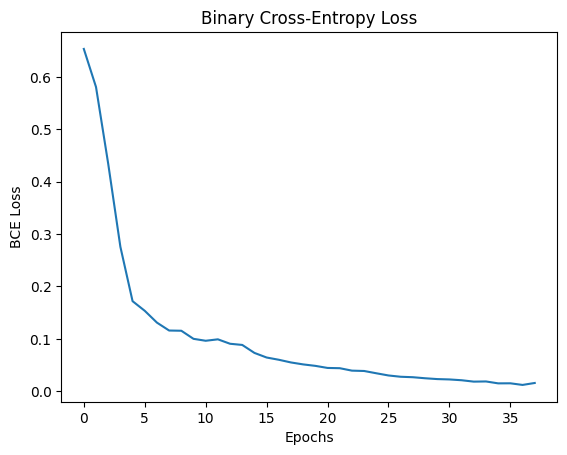

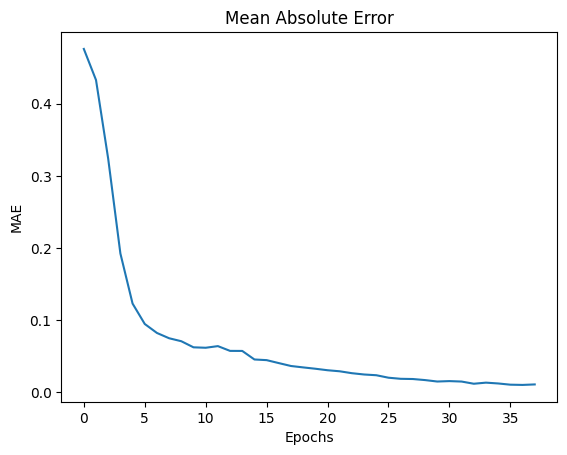

In [60]:
plt.plot(history_loss)
plt.title("Binary Cross-Entropy Loss")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.savefig('../images/training_loss.png', dpi=100, bbox_inches='tight')
plt.show()

plt.plot(history_mae)
plt.title("Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.show()

Oba grafy ukazují správný průběh trénování. Loss i MAE plynule klesají.

### Matice záměn
Stejně jako u SVM modelu zobrazíme matici záměn, která ukazuje
kolik případů bylo správně a chybně klasifikováno.

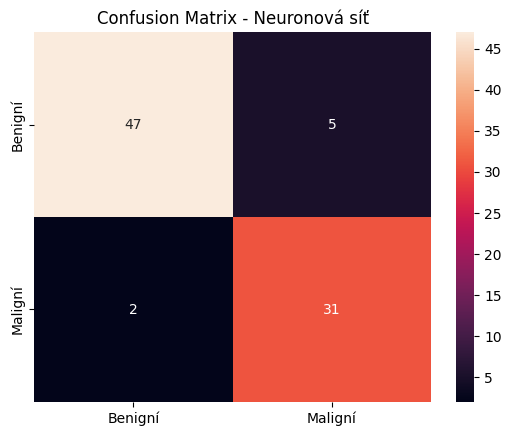

In [61]:
cf_matrix = confusion_matrix(y_val_torch.numpy().flatten(), y_pred.flatten())
sns.heatmap(cf_matrix, annot=True, fmt='d',
            xticklabels=['Benigní', 'Maligní'],
            yticklabels=['Benigní', 'Maligní'])
plt.title("Confusion Matrix - Neuronová síť")
plt.savefig('../images/confusion_matrix_nn.png', dpi=100, bbox_inches='tight')

- 47 správně označeno jako benigní (True Negative)
- 31 správně označeno jako maligní (True Positive)
- 5 benigní označeno jako maligní (False Positive)
- 2 maligní označeno jako benigní (False Negative)

Kritická chyba nastala pouze dvakrát. Model označil maligní nádor jako benigní, stejně jako SVM.
Oproti SVM se však snížil počet False Positive ze 6 na 5, což znamená méně zbytečných obav pro pacienty.

## 4.5 Uložení modelu
Uložení naučených parametrů modelu do souboru

In [62]:
torch.save(model.state_dict(), "classification_model.pt")
print("Model úspěšně uložen.")

Model úspěšně uložen.


# 5. Porovnání modelů
Porovnáme oba natrénované model: SVM (GridSearchCV) a neuronovou síť (PyTorch) na stejných testovacích  datech.

In [63]:
y_pred_svm = clf.predict(X_test)
print("SVM (GridSearchCV):")
print(f"Přesnost: {accuracy_score(y_test, y_pred_svm)*100:.2f} %")
print(classification_report(y_test, y_pred_svm, target_names=['Benigní', 'Maligní']))

SVM (GridSearchCV):
Přesnost: 96.55 %
              precision    recall  f1-score   support

     Benigní       0.97      0.97      0.97        37
     Maligní       0.95      0.95      0.95        21

    accuracy                           0.97        58
   macro avg       0.96      0.96      0.96        58
weighted avg       0.97      0.97      0.97        58



In [64]:
# Spuštění neuronové sítě na testovacích datech
model.eval()
with torch.no_grad():
    X_test_torch = X_test_torch.to(device)
    y_pred_ann = model(X_test_torch)
    y_pred_ann = (y_pred_ann >= 0.5).float().detach().cpu().numpy().flatten()

print("Neuronová síť (PyTorch):")
print(f"Přesnost: {accuracy_score(y_test, y_pred_ann)*100:.2f} %")
print(classification_report(y_test, y_pred_ann, target_names=['Benigní', 'Maligní']))

Neuronová síť (PyTorch):
Přesnost: 96.55 %
              precision    recall  f1-score   support

     Benigní       1.00      0.95      0.97        37
     Maligní       0.91      1.00      0.95        21

    accuracy                           0.97        58
   macro avg       0.96      0.97      0.96        58
weighted avg       0.97      0.97      0.97        58



## Závěr porovnání

Na testovacích datech dosáhly **oba modely shodné přesnosti 96,55 %** (56 správně z 58 vzorků). Na validačních datech (85 vzorků) oba modely také dosáhly shodné přesnosti **92,94 %**.

Důležité ale je, **jakých chyb** se modely dopouštějí. V medicíně je **False Negative** (maligní nádor označený jako benigní) mnohem závažnější než False Positive, protože vede k nediagnostikované rakovině.

| Metrika (třída Maligní) | SVM | Neuronová síť |
|---|---|---|
| Precision | 0,95 | 0,91 |
| Recall | 0,95 | **1,00** |
| F1-score | 0,95 | 0,95 |

Neuronová síť dosáhla **recall = 1,00**, tedy **nepřehlédla ani jeden maligní nádor**. SVM jeden případ chybně označil jako benigní.

Na validační sadě měly oba modely stejný počet kritických chyb (2× FN), neuronová síť však generovala méně falešných poplachů (4 FP vs. 6 FP).

**Závěr:** Oba modely jsou srovnatelné, ale pro medicínské nasazení je **vhodnější neuronová síť**, protože minimalizuje riziko přehlédnutí rakoviny. Výsledky je však třeba brát s rezervou kvůli malé testovací sadě (58 vzorků).

